In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
import warnings
warnings.filterwarnings('ignore')

# Chart styling — these settings make your charts look professional
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 10,
})
sns.set_palette("husl")

# Paths — everything relative to the notebooks/ folder
DATA_DIR = Path('../data/raw')
DOCS_DIR = Path('../docs')
DOCS_DIR.mkdir(exist_ok=True)

print("✓ Libraries imported")
print(f"✓ Looking for data in: {DATA_DIR.resolve()}")

C:\Users\User\AppData\Local\Temp\ipykernel_10544\4154327919.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


✓ Libraries imported
✓ Looking for data in: C:\Users\User\Documents\cybersentinel-ai\data\raw


In [2]:
FILE_NAMES = [
    'Monday-WorkingHours.pcap_ISCX.csv',
    'Tuesday-WorkingHours.pcap_ISCX.csv',
    'Wednesday-workingHours.pcap_ISCX.csv',
    'Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv',
    'Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv',
    'Friday-WorkingHours-Morning.pcap_ISCX.csv',
    'Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv',
    'Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv',
]

dfs = []
print("Loading CIC-IDS2017 dataset files...")
print("-" * 55)

for fname in FILE_NAMES:
    fpath = DATA_DIR / fname
    if not fpath.exists():
        print(f"  ⏭  {fname.split('-')[0]}: not found yet — skipping")
        continue

    df_day = pd.read_csv(fpath, encoding='utf-8', low_memory=False)
    # Tag each row with which day it came from
    df_day['source_day'] = fname.split('-WorkingHours')[0].split('-')[0]
    dfs.append(df_day)
    print(f"  ✓  {fname.split('-WorkingHours')[0]:<40} {len(df_day):>9,} rows")

if not dfs:
    print("\n⚠  No files found. Check that CSVs are in data/raw/")
    print("   Use the NSL-KDD placeholder from Step 6 while you wait for the download.")
else:
    df = pd.concat(dfs, ignore_index=True)
    mem_mb = df.memory_usage(deep=True).sum() / 1024**2
    print(f"\n{'─'*55}")
    print(f"  Total rows:    {len(df):>12,}")
    print(f"  Total columns: {len(df.columns):>12,}")
    print(f"  Memory usage:  {mem_mb:>11.1f} MB")

Loading CIC-IDS2017 dataset files...
-------------------------------------------------------
  ✓  Monday                                     529,918 rows
  ✓  Tuesday                                    445,909 rows
  ✓  Wednesday-workingHours.pcap_ISCX.csv       692,703 rows
  ✓  Thursday                                   170,366 rows
  ✓  Thursday                                   288,602 rows
  ✓  Friday                                     191,033 rows
  ✓  Friday                                     286,467 rows
  ✓  Friday                                     225,745 rows

───────────────────────────────────────────────────────
  Total rows:       2,830,743
  Total columns:           80
  Memory usage:       2028.8 MB


In [3]:
# QUIRK 1: Many column names have a leading space — strip it
df.columns = df.columns.str.strip()

# QUIRK 2: Some CSV versions call the label column " Label" (with space)
if ' Label' in df.columns:
    df.rename(columns={' Label': 'Label'}, inplace=True)

# QUIRK 3: Label values also have leading/trailing spaces
df['Label'] = df['Label'].str.strip()

# QUIRK 4: Features like "Flow Bytes/s" contain infinity values
# (e.g. a flow with 0 duration → division by zero when calculating bytes/second)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
inf_mask = np.isinf(df[numeric_cols])
inf_count = inf_mask.sum().sum()

# Replace infinities with NaN so we can handle them cleanly in Phase 2
df[numeric_cols] = df[numeric_cols].replace([np.inf, -np.inf], np.nan)
print(f"Replaced {inf_count:,} infinity values with NaN ✓")

# Show all unique attack labels
print(f"\n{'Label':<45} {'Count':>10}  {'%':>6}")
print("─" * 65)
for label, count in df['Label'].value_counts().items():
    pct = count / len(df) * 100
    bar = '█' * max(1, int(pct / 3))
    marker = "  ← BENIGN (normal traffic)" if label == 'BENIGN' else ""
    print(f"  {label:<43} {count:>9,}  {pct:>5.1f}%  {bar}{marker}")

Replaced 4,376 infinity values with NaN ✓

Label                                              Count       %
─────────────────────────────────────────────────────────────────
  BENIGN                                      2,273,097   80.3%  ██████████████████████████  ← BENIGN (normal traffic)
  DoS Hulk                                      231,073    8.2%  ██
  PortScan                                      158,930    5.6%  █
  DDoS                                          128,027    4.5%  █
  DoS GoldenEye                                  10,293    0.4%  █
  FTP-Patator                                     7,938    0.3%  █
  SSH-Patator                                     5,897    0.2%  █
  DoS slowloris                                   5,796    0.2%  █
  DoS Slowhttptest                                5,499    0.2%  █
  Bot                                             1,966    0.1%  █
  Web Attack � Brute Force                        1,507    0.1%  █
  Web Attack � XSS                  

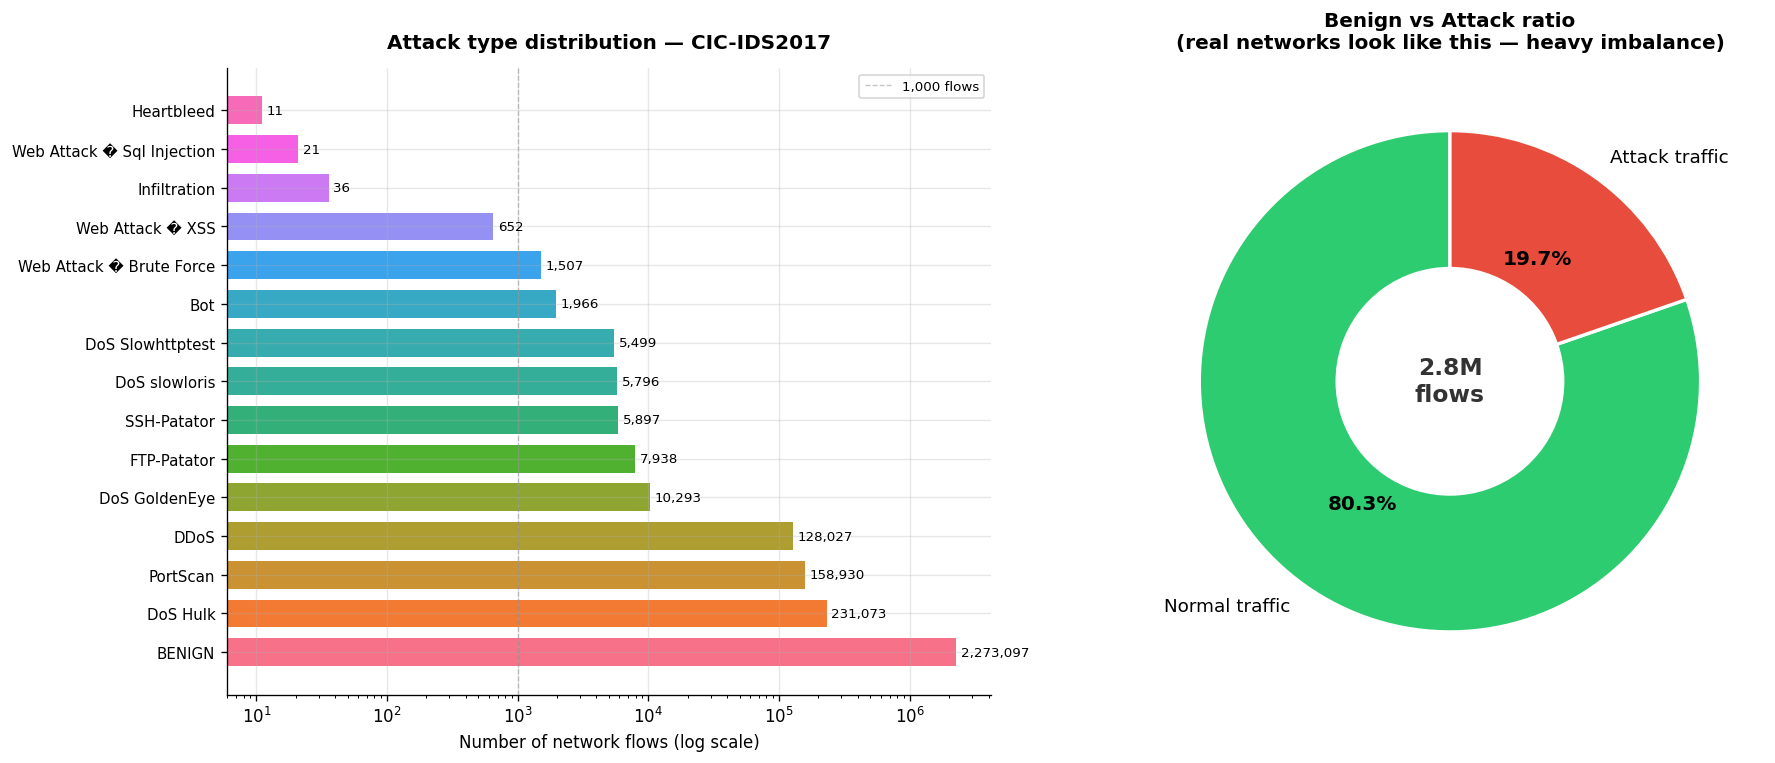

✓ Saved to docs/01_attack_distribution.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

attack_counts = df['Label'].value_counts()
n_types = len(attack_counts)
colors = sns.color_palette("husl", n_types)

# ── Left: Horizontal bar chart (log scale because BENIGN dominates) ──────────
bars = axes[0].barh(
    range(n_types),
    attack_counts.values,
    color=colors,
    height=0.72,
    edgecolor='none',
)
axes[0].set_yticks(range(n_types))
axes[0].set_yticklabels(attack_counts.index, fontsize=9)
axes[0].set_xlabel("Number of network flows (log scale)", fontsize=10)
axes[0].set_title("Attack type distribution — CIC-IDS2017",
                  fontsize=12, fontweight='bold', pad=12)
axes[0].set_xscale('log')
# Reference line at 1,000 flows
axes[0].axvline(x=1000, color='#888', linestyle='--', alpha=0.5,
                linewidth=0.8, label='1,000 flows')
axes[0].legend(fontsize=8)

# Add count labels to each bar
for bar, count in zip(bars, attack_counts.values):
    axes[0].text(
        bar.get_width() * 1.08,
        bar.get_y() + bar.get_height() / 2,
        f'{count:,}',
        va='center', ha='left', fontsize=8
    )

# ── Right: Donut chart — the big picture ─────────────────────────────────────
binary = df['Label'].apply(
    lambda x: 'Normal traffic' if x == 'BENIGN' else 'Attack traffic'
).value_counts()

wedge_colors = ['#2ecc71', '#e74c3c']
wedges, texts, autotexts = axes[1].pie(
    binary.values,
    labels=binary.index,
    autopct='%1.1f%%',
    colors=wedge_colors,
    startangle=90,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2),
    textprops={'fontsize': 11},
)
for at in autotexts:
    at.set_fontsize(12)
    at.set_fontweight('bold')

# Center text showing total
total_m = len(df) / 1_000_000
axes[1].text(0, 0, f'{total_m:.1f}M\nflows', ha='center', va='center',
             fontsize=14, fontweight='bold', color='#333')
axes[1].set_title(
    "Benign vs Attack ratio\n(real networks look like this — heavy imbalance)",
    fontsize=12, fontweight='bold', pad=12
)

plt.tight_layout(pad=3)
plt.savefig(DOCS_DIR / '01_attack_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved to docs/01_attack_distribution.png")

In [5]:
print("=" * 60)
print("  DATA QUALITY REPORT")
print("=" * 60)

# Missing values
missing = df[numeric_cols].isnull().sum()
missing_cols = missing[missing > 0].sort_values(ascending=False)

print(f"\n  Numeric features:   {len(numeric_cols)}")
print(f"  String features:    {len(df.select_dtypes(include='object').columns) - 2}")
print(f"  Total rows:         {len(df):,}")

print(f"\n  Columns with NaN (after inf→NaN replacement):")
if len(missing_cols) > 0:
    for col, cnt in missing_cols.head(12).items():
        pct = cnt / len(df) * 100
        print(f"    {col:<42} {cnt:>8,}  ({pct:.1f}%)")
    if len(missing_cols) > 12:
        print(f"    ... and {len(missing_cols) - 12} more columns")
else:
    print("    ✓ None — dataset is clean after inf replacement!")

# Class imbalance — this is the key insight
benign_n  = (df['Label'] == 'BENIGN').sum()
attack_n  = len(df) - benign_n
ratio     = benign_n / attack_n

print(f"\n  Class imbalance (the biggest ML challenge here):")
print(f"    Benign flows:    {benign_n:>10,}  ({benign_n/len(df)*100:.1f}%)")
print(f"    Attack flows:    {attack_n:>10,}  ({attack_n/len(df)*100:.1f}%)")
print(f"    Imbalance ratio: {ratio:.1f}:1  (benign:attack)")
print(f"\n  ⚠  If you train a naive model, it can reach ~80% accuracy")
print(f"     just by predicting 'BENIGN' for everything — and be useless.")
print(f"     Phase 2 fixes this with SMOTE oversampling.")
print(f"\n  Attack types detected: {df['Label'].nunique() - 1}")
print("=" * 60)

  DATA QUALITY REPORT

  Numeric features:   78
  String features:    0
  Total rows:         2,830,743

  Columns with NaN (after inf→NaN replacement):
    Flow Bytes/s                                  2,867  (0.1%)
    Flow Packets/s                                2,867  (0.1%)

  Class imbalance (the biggest ML challenge here):
    Benign flows:     2,273,097  (80.3%)
    Attack flows:       557,646  (19.7%)
    Imbalance ratio: 4.1:1  (benign:attack)

  ⚠  If you train a naive model, it can reach ~80% accuracy
     just by predicting 'BENIGN' for everything — and be useless.
     Phase 2 fixes this with SMOTE oversampling.

  Attack types detected: 14


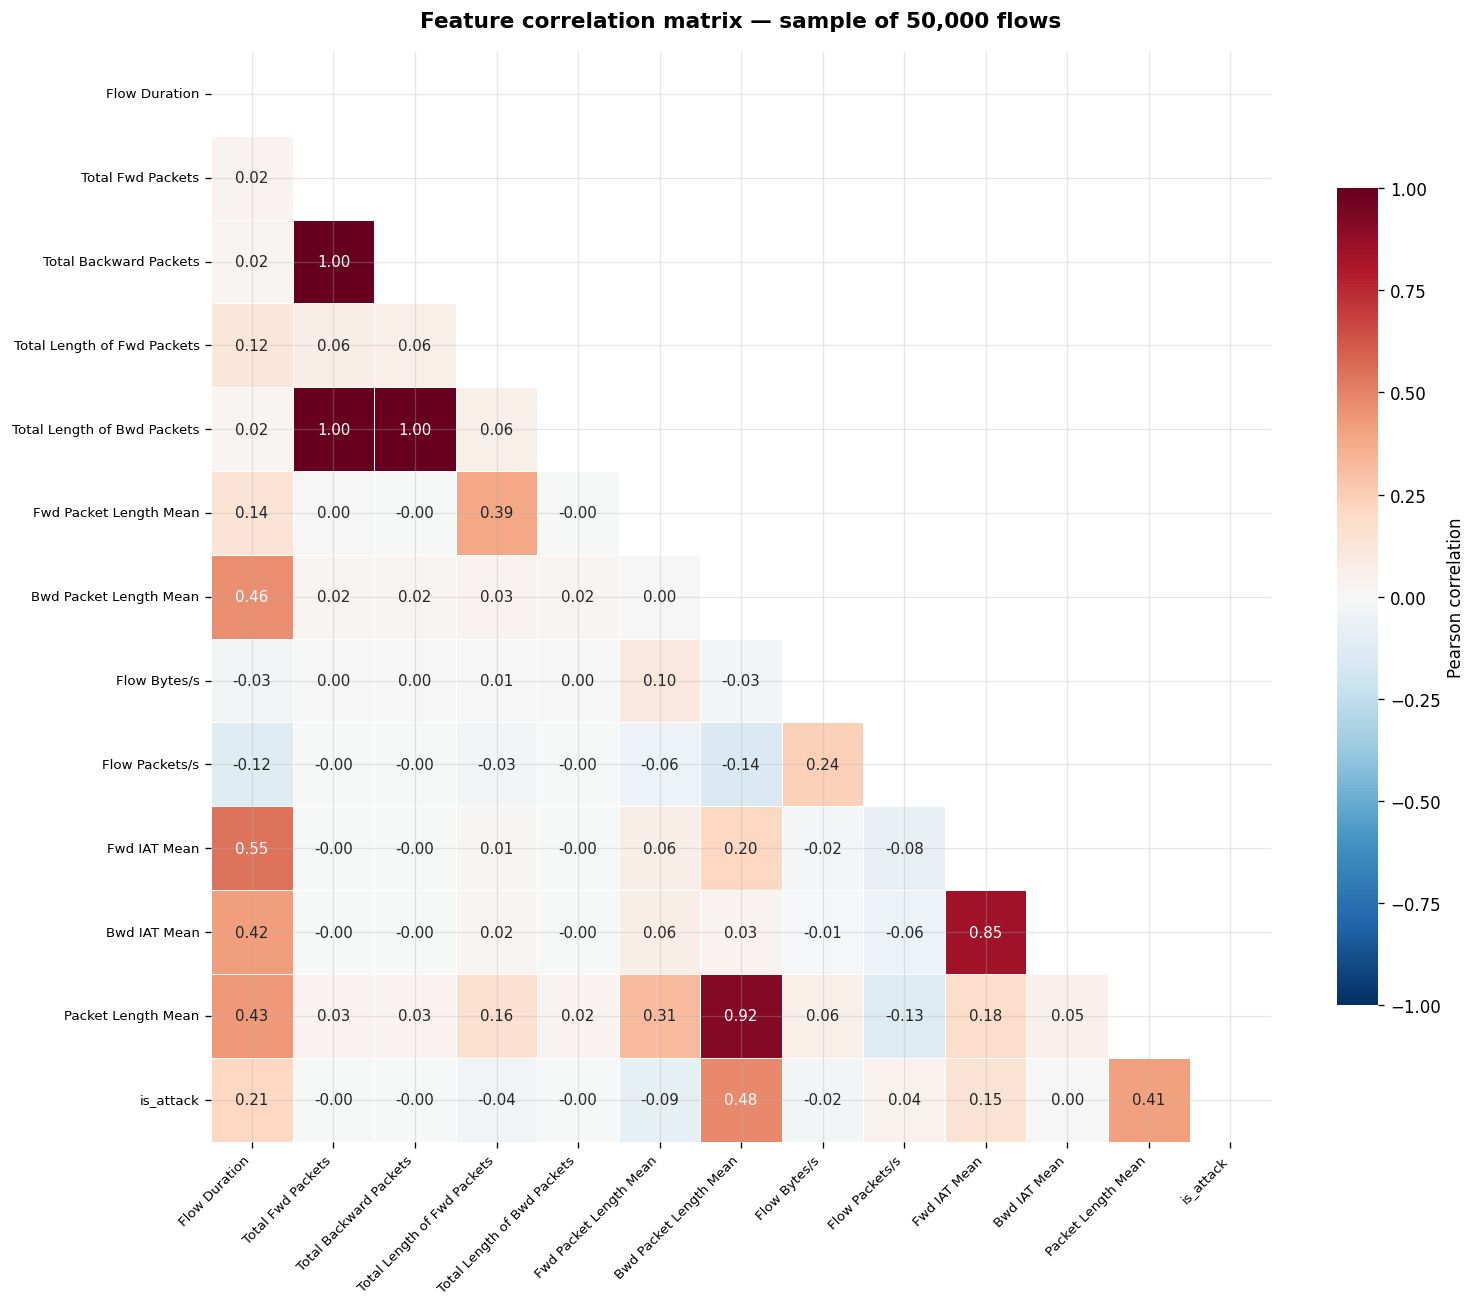

Features most strongly correlated with attack label:
(These become your model's most useful 'clues')

  Bwd Packet Length Mean                   0.478  ██████████████
  Packet Length Mean                       0.408  ████████████
  Flow Duration                            0.210  ██████
  Fwd IAT Mean                             0.145  ████
  Fwd Packet Length Mean                   0.091  ██
  Flow Packets/s                           0.042  █
  Total Length of Fwd Packets              0.037  █
  Flow Bytes/s                             0.024  

✓ Saved to docs/02_correlation_matrix.png


In [6]:
KEY_FEATURES = [
    'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets',
    'Total Length of Fwd Packets', 'Total Length of Bwd Packets',
    'Fwd Packet Length Mean', 'Bwd Packet Length Mean',
    'Flow Bytes/s', 'Flow Packets/s',
    'Fwd IAT Mean', 'Bwd IAT Mean', 'Packet Length Mean',
]
existing = [f for f in KEY_FEATURES if f in df.columns]

# Sample 50,000 rows — computing correlations on 2.8M rows is slow
sample = df[existing + ['Label']].sample(min(50_000, len(df)), random_state=42).copy()
sample['is_attack'] = (sample['Label'] != 'BENIGN').astype(int)
sample = sample.drop('Label', axis=1).fillna(0)

fig, ax = plt.subplots(figsize=(13, 11))
corr = sample.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # Show only lower triangle

sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, ax=ax,
    vmin=-1, vmax=1,
    linewidths=0.3, linecolor='white',
    cbar_kws={'shrink': 0.75, 'label': 'Pearson correlation'},
    annot_kws={'size': 9}
)
ax.set_title("Feature correlation matrix — sample of 50,000 flows",
             fontsize=13, fontweight='bold', pad=15)
plt.xticks(fontsize=8, rotation=45, ha='right')
plt.yticks(fontsize=8, rotation=0)
plt.tight_layout()
plt.savefig(DOCS_DIR / '02_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Print the features most correlated with the attack label
print("Features most strongly correlated with attack label:")
print("(These become your model's most useful 'clues')\n")
corr_attack = sample.corr()['is_attack'].drop('is_attack').abs().sort_values(ascending=False)
for feat, val in corr_attack.head(8).items():
    bar = '█' * int(val * 30)
    print(f"  {feat:<40} {val:.3f}  {bar}")
print("\n✓ Saved to docs/02_correlation_matrix.png")

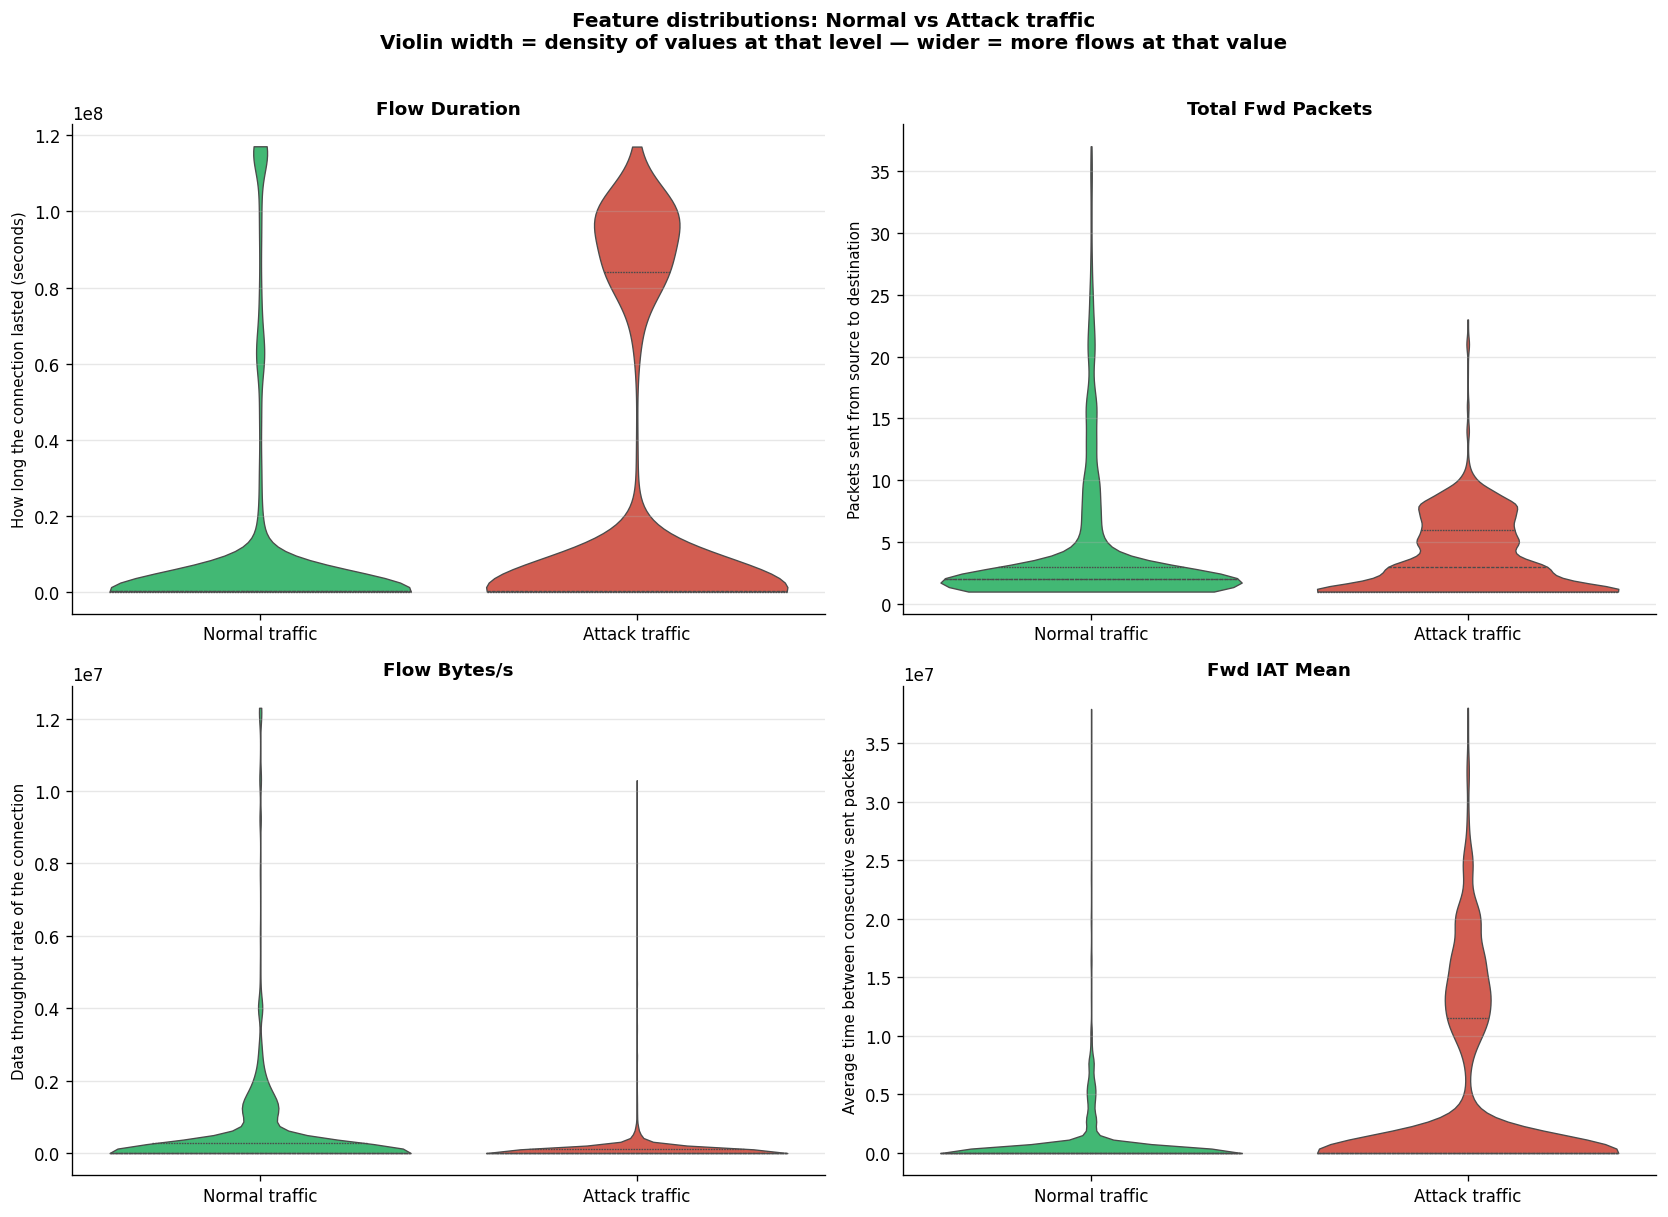

✓ Saved to docs/03_feature_distributions.png

What you are seeing:
  When the shapes look DIFFERENT between green and red, that feature
  is useful for detecting attacks. The more different, the better.
  Your ML models will learn to use all 80 features simultaneously.


In [7]:
# These four features tend to look very different between normal and attack traffic
FEATURES_TO_COMPARE = [
    ('Flow Duration',        'How long the connection lasted (seconds)'),
    ('Total Fwd Packets',    'Packets sent from source to destination'),
    ('Flow Bytes/s',         'Data throughput rate of the connection'),
    ('Fwd IAT Mean',         'Average time between consecutive sent packets'),
]
existing_pairs = [(f, d) for f, d in FEATURES_TO_COMPARE if f in df.columns]

# Sample equally from benign and attack classes for fair comparison
n_per_class = 5_000
df_plot = pd.concat([
    df[df['Label'] == 'BENIGN'].sample(min(n_per_class, benign_n), random_state=42),
    df[df['Label'] != 'BENIGN'].sample(min(n_per_class, attack_n), random_state=42)
]).copy()
df_plot['Traffic type'] = df_plot['Label'].apply(
    lambda x: 'Normal traffic' if x == 'BENIGN' else 'Attack traffic'
)
df_plot = df_plot.replace([np.inf, -np.inf], np.nan)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
palette = {'Normal traffic': '#2ecc71', 'Attack traffic': '#e74c3c'}

for i, (feature, description) in enumerate(existing_pairs[:4]):
    col_data = df_plot[[feature, 'Traffic type']].dropna()
    # Clip to 99th percentile so extreme outliers don't crush the chart
    p99 = col_data[feature].quantile(0.99)
    col_data = col_data[col_data[feature] <= p99]

    # Violin plot shows the full distribution shape — more informative than a bar chart
    sns.violinplot(
        data=col_data,
        x='Traffic type', y=feature,
        palette=palette,
        ax=axes[i],
        inner='quartile',   # Show median and quartiles inside
        cut=0,              # Do not extend beyond observed range
        linewidth=0.8,
    )
    axes[i].set_title(f"{feature}", fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel(f"{description}", fontsize=9)

plt.suptitle(
    "Feature distributions: Normal vs Attack traffic\n"
    "Violin width = density of values at that level — wider = more flows at that value",
    fontsize=12, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig(DOCS_DIR / '03_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved to docs/03_feature_distributions.png")
print()
print("What you are seeing:")
print("  When the shapes look DIFFERENT between green and red, that feature")
print("  is useful for detecting attacks. The more different, the better.")
print("  Your ML models will learn to use all 80 features simultaneously.")

In [8]:
# Save a JSON summary that gets used by later phases
summary = {
    'total_flows':       int(len(df)),
    'n_numeric_features': int(len(numeric_cols)),
    'n_attack_types':    int(df['Label'].nunique() - 1),
    'benign_count':      int(benign_n),
    'attack_count':      int(attack_n),
    'imbalance_ratio':   round(float(benign_n / attack_n), 2),
    'missing_value_cols': int(len(missing_cols)),
    'attack_type_counts': {
        label: int(count)
        for label, count in df['Label'].value_counts().items()
        if label != 'BENIGN'
    },
    'feature_names': numeric_cols[:80],   # Save for Phase 2
}

with open('../data/eda_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print("=" * 55)
print("  PHASE 1 COMPLETE")
print("=" * 55)
print(f"  Dataset:        {summary['total_flows']:,} network flows")
print(f"  Features:       {summary['n_numeric_features']} numeric features")
print(f"  Attack types:   {summary['n_attack_types']}")
print(f"  Class ratio:    {summary['imbalance_ratio']:.1f}:1 benign:attack")
print(f"  Charts saved:   docs/")
print(f"  Summary saved:  data/eda_summary.json")
print()
print("  Run these commands to commit and push:")
print()
print("    cd ..")
print("    git add notebooks/ docs/ data/eda_summary.json")
print("    git commit -m 'Phase 1: EDA complete — CIC-IDS2017 analysis'")
print("    git push origin main")

  PHASE 1 COMPLETE
  Dataset:        2,830,743 network flows
  Features:       78 numeric features
  Attack types:   14
  Class ratio:    4.1:1 benign:attack
  Charts saved:   docs/
  Summary saved:  data/eda_summary.json

  Run these commands to commit and push:

    cd ..
    git add notebooks/ docs/ data/eda_summary.json
    git commit -m 'Phase 1: EDA complete — CIC-IDS2017 analysis'
    git push origin main
